# Complejidad computacional: ¿cuánto cuesta entrenar cada modelo?

**Pregunta.** ¿Cómo crece el tiempo de entrenamiento de cada modelo con el número de observaciones y de variables, y en qué casos conviene el aprendizaje en línea?

**Método.** Se entrena cada modelo con datos simulados de distinto tamaño y se mide el tiempo. Luego se ajusta la relación

$$\text{tiempo} = c \cdot n^{a} \cdot p^{b}$$

con una regresión en logaritmos, donde $n$ es el número de observaciones y $p$ el de variables. Un exponente $a$ de 1 significa que duplicar los datos duplica el tiempo. Es la misma idea del evaluador de complejidad de la tesis, actualizada.

**Resultado principal.** Todos los modelos escalan de forma casi lineal con el número de observaciones. Por observación, los modelos en línea de river son unas 30 veces más lentos que sus equivalentes por lotes de scikit-learn, en gran parte porque procesan cada dato en Python. Sin embargo, cuando el modelo debe mantenerse al día con datos que llegan continuamente, reentrenar por lotes con toda la historia resulta más caro que aprender en línea.

## 1. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from river import ensemble, naive_bayes, tree
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from dsaplicado import datos, en_linea
from dsaplicado.graficos import COLORES, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo

aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)

RAIZ = datos.raiz_repositorio()
CARPETA = RAIZ / "04_aprendizaje_en_linea"
(CARPETA / "resultados").mkdir(exist_ok=True)
ARCHIVO_TIEMPOS = CARPETA / "resultados" / "tiempos_complejidad.csv"
MEDIR_DE_NUEVO = False   # True vuelve a medir; tarda varios minutos y depende del computador

def generar(n, p):
    X, y = make_classification(n_samples=n, n_features=p, n_informative=max(2, p // 2), random_state=0)
    return X, y

def en_linea_desde(fabrica):
    def entrenar(X, y):
        modelo = fabrica()
        nombres = [f"x{i}" for i in range(X.shape[1])]
        for fila, etiqueta in zip(X, y):
            modelo.learn_one(dict(zip(nombres, fila)), etiqueta)
    return entrenar

MODELOS = {
    "Naive Bayes por lotes": ("lotes", lambda X, y: GaussianNB().fit(X, y)),
    "Bagging de Naive Bayes por lotes": ("lotes", lambda X, y: BaggingClassifier(GaussianNB(), n_estimators=10, random_state=0).fit(X, y)),
    "Bosque aleatorio por lotes": ("lotes", lambda X, y: RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=1).fit(X, y)),
    "Naive Bayes en línea": ("en línea", en_linea_desde(naive_bayes.GaussianNB)),
    "Bagging de Oza en línea": ("en línea", en_linea_desde(lambda: ensemble.BaggingClassifier(naive_bayes.GaussianNB(), n_models=10, seed=0))),
    "Árbol de Hoeffding en línea": ("en línea", en_linea_desde(tree.HoeffdingTreeClassifier)),
}
# Los modelos por lotes están optimizados en C y se miden con más datos; los en línea procesan en Python.
GRILLAS = {"lotes": ([10_000, 20_000, 40_000, 80_000, 160_000], [5, 10, 20, 40], 5),
           "en línea": ([2_000, 4_000, 8_000, 16_000, 32_000], [5, 10, 20], 1)}

## 2. Medición

Las mediciones se guardan en un archivo. Así el notebook muestra siempre los mismos resultados, que se obtuvieron en un solo computador, y no cambian cada vez que se ejecuta en otra máquina.

In [2]:
if ARCHIVO_TIEMPOS.exists() and not MEDIR_DE_NUEVO:
    tiempos = pd.read_csv(ARCHIVO_TIEMPOS)
else:
    partes = []
    for nombre, (tipo, entrenar) in MODELOS.items():
        filas, columnas, repeticiones = GRILLAS[tipo]
        medicion = en_linea.medir_tiempos(entrenar, generar, filas, columnas, repeticiones)
        medicion.insert(0, "tipo", tipo)
        medicion.insert(0, "modelo", nombre)
        partes.append(medicion)
    tiempos = pd.concat(partes, ignore_index=True)
    tiempos.to_csv(ARCHIVO_TIEMPOS, index=False)
print(f"{len(tiempos)} mediciones de {tiempos['modelo'].nunique()} modelos")

105 mediciones de 6 modelos


## 3. Exponentes de complejidad

In [3]:
exponentes = pd.DataFrame({m: en_linea.exponentes_complejidad(g) for m, g in tiempos.groupby("modelo", sort=False)}).T
exponentes["tipo"] = [MODELOS[m][0] for m in exponentes.index]
p_comun = 10
por_observacion = (tiempos[tiempos["columnas"] == p_comun]
                   .assign(microsegundos=lambda d: 1e6 * d["segundos"] / d["filas"])
                   .groupby("modelo", sort=False)["microsegundos"].median())
exponentes["microsegundos por observación"] = por_observacion
exponentes

,exponente_filas,exponente_columnas,r2,tipo,microsegundos por observación
Naive Bayes por lotes,1.032,0.506,0.984,lotes,0.309
Bagging de Naive Bayes por lotes,0.939,0.476,0.968,lotes,3.731
Bosque aleatorio por lotes,1.162,0.491,0.997,lotes,128.344
Naive Bayes en línea,1.015,0.847,0.999,en línea,10.272
Bagging de Oza en línea,0.996,0.802,0.999,en línea,107.756
Árbol de Hoeffding en línea,1.017,0.674,0.999,en línea,66.859


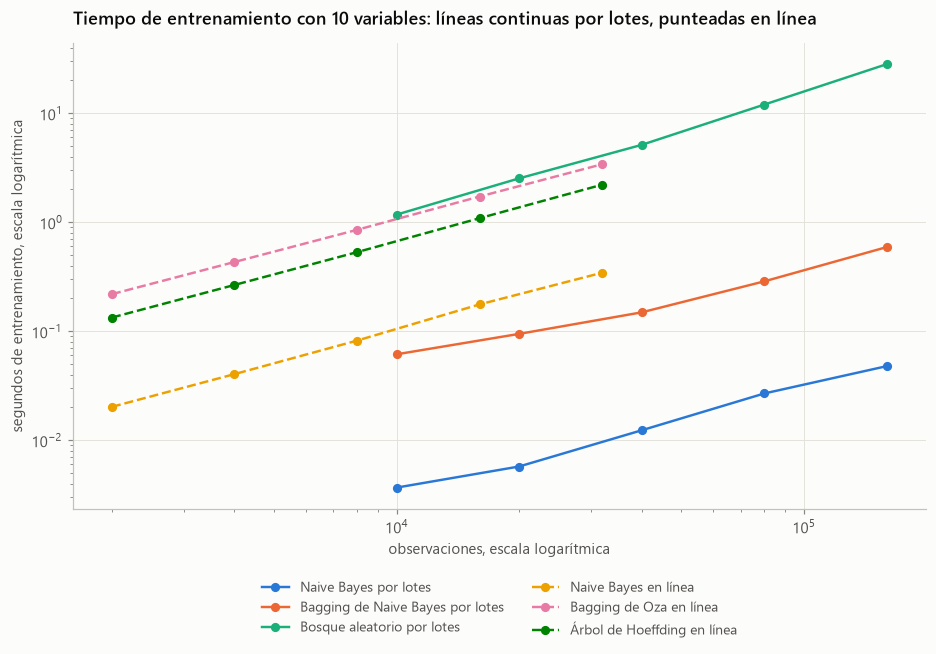

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for k, (nombre, grupo) in enumerate(tiempos[tiempos["columnas"] == p_comun].groupby("modelo", sort=False)):
    tipo = MODELOS[nombre][0]
    ax.plot(grupo["filas"], grupo["segundos"], marker="o", markersize=5, color=COLORES[k],
            linestyle="-" if tipo == "lotes" else "--", label=nombre)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("observaciones, escala logarítmica")
ax.set_ylabel("segundos de entrenamiento, escala logarítmica")
ax.set_title(f"Tiempo de entrenamiento con {p_comun} variables: líneas continuas por lotes, punteadas en línea")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncols=2, fontsize=9)
fig.savefig(CARPETA / "figuras" / "complejidad.png", bbox_inches="tight")
plt.show()

**Lectura.**

- **Crecimiento lineal en observaciones.** Los exponentes de filas van de 0,94 a 1,16. Duplicar los datos duplica aproximadamente el tiempo, y el bosque aleatorio crece algo más rápido por el ordenamiento que hace al construir cada árbol.
- **Crecimiento menor en variables.** Los exponentes de columnas son de 0,5 en los modelos por lotes y de 0,7 a 0,85 en los en línea. Los modelos por lotes procesan todas las variables juntas con operaciones vectorizadas; los en línea recorren un diccionario por observación.
- **Costo por observación.** Con 10 variables, Naive Bayes por lotes procesa una observación en 0,3 microsegundos y Naive Bayes en línea en 10. La diferencia es de unas 30 veces, y viene sobre todo del lenguaje de implementación.

## 4. El costo de mantener el modelo actualizado

En un flujo de datos, el modelo debe incorporar lo que llega. Un modelo por lotes lo hace reentrenándose con toda la historia acumulada; uno en línea solo procesa las observaciones nuevas. Con los costos por observación medidos arriba, se estima el tiempo total de mantener cada modelo al día durante 100.000 observaciones, reentrenando el modelo por lotes cada 1.000.

In [5]:
TOTAL, CADA = 100_000, 1_000
observaciones_reprocesadas = sum(range(CADA, TOTAL + 1, CADA))  # cada reentrenamiento usa toda la historia
parejas = [("Naive Bayes por lotes", "Naive Bayes en línea"),
           ("Bagging de Naive Bayes por lotes", "Bagging de Oza en línea"),
           ("Bosque aleatorio por lotes", "Árbol de Hoeffding en línea")]
costo = pd.DataFrame([{
    "modelo por lotes": lotes, "modelo en línea": linea,
    "segundos por lotes": exponentes.loc[lotes, "microsegundos por observación"] * observaciones_reprocesadas / 1e6,
    "segundos en línea": exponentes.loc[linea, "microsegundos por observación"] * TOTAL / 1e6,
} for lotes, linea in parejas])
costo["veces más caro por lotes"] = costo["segundos por lotes"] / costo["segundos en línea"]
print(f"El modelo por lotes procesa {observaciones_reprocesadas:,} observaciones en total; el en línea, {TOTAL:,}.")
costo

El modelo por lotes procesa 5,050,000 observaciones en total; el en línea, 100,000.


,modelo por lotes,modelo en línea,segundos por lotes,segundos en línea,veces más caro por lotes
0,Naive Bayes por lotes,Naive Bayes en línea,1.560,1.027,1.518
1,Bagging de Naive Bayes por lotes,Bagging de Oza en línea,18.840,10.776,1.748
2,Bosque aleatorio por lotes,Árbol de Hoeffding en línea,648.137,6.686,96.940


**Lectura.** Para mantener un modelo actualizado, la comparación relevante no es el costo por observación sino el costo acumulado. Reentrenar cada 1.000 observaciones obliga al modelo por lotes a procesar 5 millones de observaciones en total, 50 veces más que el modelo en línea. Con Naive Bayes, esa diferencia compensa la lentitud por observación y ambos quedan en un orden de magnitud similar. Con modelos caros como el bosque aleatorio, reentrenar por lotes cuesta cerca de cien veces más que actualizar un árbol de Hoeffding.

## 5. Conclusiones

1. **Ambos enfoques escalan de forma lineal con los datos.** Ninguno de los modelos evaluados tiene un costo que explote al crecer la muestra.
2. **Entrenar una vez es más barato por lotes.** Si los datos caben en memoria y no cambian, scikit-learn es mucho más rápido.
3. **Mantener el modelo al día favorece al aprendizaje en línea.** Cuando los datos llegan de forma continua, el costo de reentrenar con toda la historia crece con el cuadrado del tiempo, mientras el aprendizaje en línea crece de forma lineal.
4. **La elección depende del problema.** El aprendizaje en línea conviene con flujos continuos, memoria limitada o fenómenos que cambian, como muestra el notebook 02.

## 6. Limitaciones

- **Un solo computador.** Los tiempos absolutos dependen del hardware. Los exponentes son más estables, pero también pueden variar.
- **Implementaciones distintas.** scikit-learn está escrito en gran parte en C, y river procesa cada observación en Python. Parte de la diferencia de costo viene del lenguaje y no del algoritmo.
- **Solo entrenamiento.** No se mide el tiempo de predicción ni el uso de memoria, que es otra ventaja de los modelos en línea: no necesitan guardar los datos.